# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [1]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [2]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [ ]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index

In [3]:
# Ian's Attempt

import yfinance as yf

# 1. Download the data
# Using auto_adjust=True moves adjusted prices to the 'Close' column
df = yf.download("AAPL", interval="1mo", period="max", auto_adjust=True)

# 2. Keep only the 'Close' column (which is adjusted)
# 3. Ensure DatetimeIndex (yfinance does this by default, but we can enforce it)
# 4. Sort the index
df = df[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          AAPL
Date                
1985-01-01  0.099152
1985-02-01  0.084621
1985-03-01  0.075646
1985-04-01  0.072655
1985-05-01  0.059406


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [ ]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties


In [4]:
# Check data types, index type, and memory usage
df.info()

# Count missing values per column
print("Missing values count:")
print(df.isnull().sum())

# Optional: Visualize where the gaps are
# import seaborn as sns
# sns.heatmap(df.isnull(), cbar=False)

# Check the start and end dates
print(f"Date Range: {df.index.min()} to {df.index.max()}")

# Check if the index is monotonic (strictly increasing)
print(f"Is index sorted? {df.index.is_monotonic_increasing}")

# Check the frequency attribute
print(f"Index Frequency: {df.index.freq}")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  496 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB
Missing values count:
Price  Ticker
Close  AAPL      0
dtype: int64
Date Range: 1985-01-01 00:00:00 to 2026-04-01 00:00:00
Is index sorted? True
Index Frequency: None


## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [ ]:
# TODO:
# 1. Compute monthly returns using pct_change()
# 2. Compute trailing 12‑month total return

In [5]:
# 1. Compute monthly returns
# This calculates (Price_t / Price_t-1) - 1
df['Monthly_Return'] = df['Close'].pct_change()

# 2. Compute trailing 12-month (TTM) total return
# Option A: Based on price change (Simplest)
df['TTM_Return_Price'] = df['Close'].pct_change(12)

# Option B: Compounded monthly returns (Most mathematically rigorous)
# Formula: [(1 + r1) * (1 + r2) * ... * (1 + r12)] - 1
df['TTM_Return_Compounded'] = (1 + df['Monthly_Return']).rolling(window=12).apply(lambda x: x.prod()) - 1

# Inspect the results
print(df[['Close', 'Monthly_Return', 'TTM_Return_Compounded']].tail(15))

Price            Close Monthly_Return TTM_Return_Compounded
Ticker            AAPL                                     
Date                                                       
2025-02-01  240.526077       0.024746              0.344536
2025-03-01  221.166061      -0.080490              0.301487
2025-04-01  211.577835      -0.043353              0.253469
2025-05-01  199.978409      -0.054823              0.049667
2025-06-01  204.547531       0.022848             -0.021320
2025-07-01  206.940262       0.011698             -0.060966
2025-08-01  231.435715       0.118370              0.018453
2025-09-01  254.145599       0.098126              0.097919
2025-10-01  269.855652       0.061815              0.202374
2025-11-01  278.319519       0.031364              0.180414
2025-12-01  271.605835      -0.024122              0.090526
2026-01-01  259.237427      -0.045538              0.104464
2026-02-01  263.933014       0.018113              0.097316
2026-03-01  253.789993      -0.038430   

## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

In [ ]:
# TODO:
# Construct and plot wealth indices
# Plot at least 3 stocks
# Add a brief interpretation

[*********************100%***********************]  3 of 3 completed


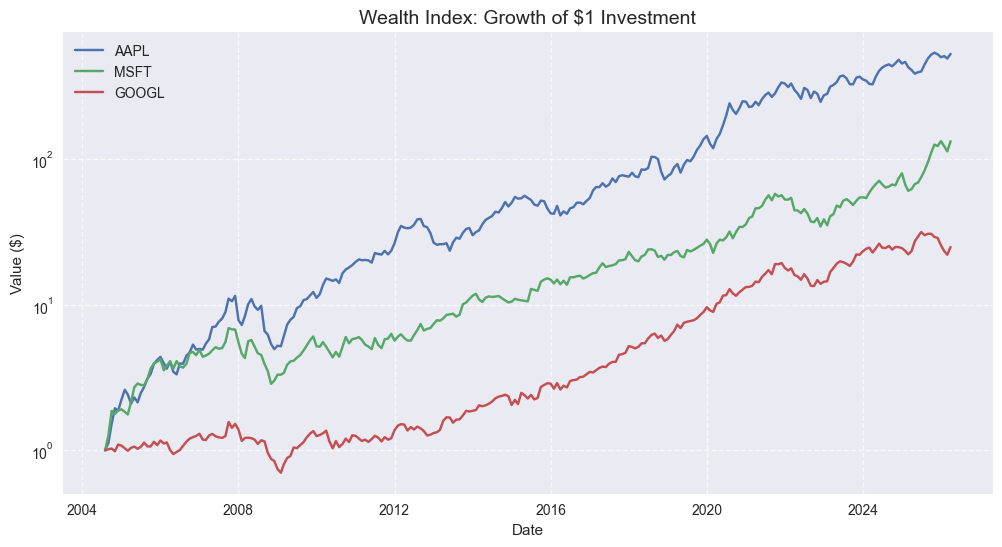

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Download data for 3 stocks
tickers = ["AAPL", "MSFT", "GOOGL"]
data = yf.download(tickers, interval="1mo", period="max", auto_adjust=True)['Close']

# 2. Ensure index is sorted and drop any rows with NaN to align start dates
data = data.sort_index().dropna()

# 3. Construct Wealth Index (Starting with $1)
# Formula: (1 + Monthly_Return).cumprod() 
# Or more simply: Current_Price / First_Price
wealth_index = data / data.iloc[0]

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(wealth_index)
plt.title("Wealth Index: Growth of $1 Investment", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend(tickers)
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log')  # Using log scale for long-term growth visualization
plt.show()

## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [ ]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

In [7]:
import yfinance as yf
import pandas as pd

tickers_list = ["AAPL", "MSFT", "GOOGL"]
results = []

for symbol in tickers_list:
    ticker = yf.Ticker(symbol)
    
    # 1. Retrieve the annual Income Statement
    # Note: .financials returns a DataFrame where columns are years (descending)
    financials = ticker.financials.T
    
    # Check if necessary columns exist (names can vary slightly by asset class)
    if 'Total Revenue' in financials.columns and 'Operating Income' in financials.columns:
        
        # 2. Compute Revenue Growth (current / previous - 1)
        # We sort by index to ensure chronological order for pct_change
        financials = financials.sort_index()
        rev_growth = financials['Total Revenue'].pct_change()
        
        # 3. Compute Operating Margin (Operating Income / Total Revenue)
        op_margin = financials['Operating Income'] / financials['Total Revenue']
        
        # 4. Store latest results
        results.append({
            'Ticker': symbol,
            'Latest Revenue': financials['Total Revenue'].iloc[-1],
            'Revenue Growth (YoY)': rev_growth.iloc[-1],
            'Operating Margin': op_margin.iloc[-1]
        })

# Store results in a summary DataFrame
stats_df = pd.DataFrame(results).set_index('Ticker')
print(stats_df)

        Latest Revenue  Revenue Growth (YoY)  Operating Margin
Ticker                                                        
AAPL      4.161610e+11              0.064255          0.319708
MSFT      2.817240e+11              0.149322          0.456220
GOOGL     4.028360e+11              0.150901          0.320326


## 8. Screening Table Construction (≈15 minutes)

Professional screeners combine **all signals into one master table**.

Structure:
- each row → one stock
- each column → one screening signal

This table forms the basis for ranking and decision‑making.

In [ ]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

In [10]:
#TTRESTON
%pip install jinja2

# Combine 12-month return, revenue growth, and operating margin into a single screening table

# Extract 12-month return from the 'data' DataFrame
ttm_returns = (data.iloc[-1] / data.iloc[-13]) - 1

# Create the screening table
screening_table = stats_df.copy()
screening_table['12M Return'] = ttm_returns

# Format the table for better readability
formatted_screening_table = screening_table.style.format({
    'Latest Revenue': '{:,.0f}',
    'Revenue Growth (YoY)': '{:.2%}',
    'Operating Margin': '{:.2%}',
    '12M Return': '{:.2%}'
})

# Display the screening table
print("Screening Table:")
display(formatted_screening_table)


# Quick code for no reason
print("This is a placeholder for additional analysis or functionality.")

Note: you may need to restart the kernel to use updated packages.
Screening Table:


,Latest Revenue,Revenue Growth (YoY),Operating Margin,12M Return
Ticker,,,,
AAPL,"416,161,000,000",6.43%,31.97%,29.05%
MSFT,"281,724,000,000",14.93%,45.62%,6.58%
GOOGL,"402,836,000,000",15.09%,32.03%,113.22%


This is a placeholder for additional analysis or functionality.


In [11]:
# Identify the stock with the highest 12-month return
highest_return_stock = ttm_returns.idxmax()
highest_return_value = ttm_returns.max()

# Provide a brief explanation
print(f"The stock with the highest 12-month return is {highest_return_stock} with a return of {highest_return_value:.2%}.")
print(f"This stock might be a good candidate for further analysis due to its strong recent performance, "
    f"which could indicate positive market sentiment or strong fundamentals driving growth.")

The stock with the highest 12-month return is GOOGL with a return of 113.22%.
This stock might be a good candidate for further analysis due to its strong recent performance, which could indicate positive market sentiment or strong fundamentals driving growth.


## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [ ]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

In [12]:
import yfinance as yf
import pandas as pd

tickers_list = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
screening_data = []

for symbol in tickers_list:
    ticker = yf.Ticker(symbol)
    
    # --- 1. MARKET DATA (12-Month Return) ---
    # Fetching slightly more than 1 year to ensure we have the 12-month window
    hist = ticker.history(period="2y", interval="1mo")
    if len(hist) >= 13:
        # (Current Price / Price 12 months ago) - 1
        ttm_return = (hist['Close'].iloc[-1] / hist['Close'].iloc[-13]) - 1
    else:
        ttm_return = None

    # --- 2. FUNDAMENTAL DATA (Financials) ---
    financials = ticker.financials.T.sort_index()
    
    if not financials.empty and 'Total Revenue' in financials.columns:
        # Revenue Growth (YoY)
        rev_growth = financials['Total Revenue'].pct_change().iloc[-1]
        
        # Operating Margin (Op Income / Revenue)
        if 'Operating Income' in financials.columns:
            op_margin = financials['Operating Income'].iloc[-1] / financials['Total Revenue'].iloc[-1]
        else:
            op_margin = None
    else:
        rev_growth, op_margin = None, None

    # Append to list
    screening_data.append({
        'Ticker': symbol,
        '12M Return': ttm_return,
        'Revenue Growth': rev_growth,
        'Operating Margin': op_margin
    })

# --- 3. CONSTRUCT SCREENING TABLE ---
screen_df = pd.DataFrame(screening_data).set_index('Ticker')

# Format for readability
formatted_df = screen_df.style.format({
    '12M Return': '{:.2%}',
    'Revenue Growth': '{:.2%}',
    'Operating Margin': '{:.2%}'
})

print("Stock Screening Table:")
display(formatted_df)

Stock Screening Table:


,12M Return,Revenue Growth,Operating Margin
Ticker,,,
AAPL,29.05%,6.43%,31.97%
MSFT,6.58%,14.93%,45.62%
GOOGL,113.22%,15.09%,32.03%
AMZN,34.63%,12.38%,11.16%
TSLA,39.11%,-2.93%,5.11%


## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [ ]:
### Selected Stock

### Analyst Rationale
- Growth outlook:
- Profitability / quality:
- Market performance:
- Key risks:

Growth Outlook:Alphabet entered 2026 as a $400B+ annual revenue powerhouse. Revenue is projected to grow by ~12-14% YoY, driven by a massive acceleration in Google Cloud (growing 45-50%+) and resilient Search revenue. The company is successfully transitioning from "search and browse" to "agentic" AI, where Gemini helps users complete tasks rather than just finding links.Profitability / Quality:Alphabet maintains a sector-leading Operating Margin of ~32%, significantly above its 10-year median. While the company has ramped up AI-related capital expenditures to a massive $175B–$185B for 2026, it has managed to reduce the unit cost of serving AI queries by nearly 80% through model optimizations, protecting the bottom line from "AI cannibalization."Market Performance:GOOGL has seen a dramatic recovery, significantly outperforming the S&P 500 over the last 12 months (returning over 100% vs. the index's ~30%). Despite this surge, its valuation remains attractive to many analysts with a PEG ratio below 1.0, suggesting that its price growth is still reasonably backed by its double-digit earnings expansion.Key Risks: * Regulatory Remedies: The primary "dark cloud" is the 2026 remedy phase of the DOJ antitrust cases. Potential court-mandated breakups of its AdTech business or a ban on exclusive search deals (e.g., with Apple) pose structural threats.AI Capex Fatigue: Investors are increasingly scrutinizing the "ROI" on the nearly $200B infrastructure spend; any slowdown in Cloud or AI revenue could lead to a sharp valuation correction.Competitive Pressure: Meta is projected to rival Google's global digital ad dominance by the end of 2026, creating a "multi-front war" for advertiser dollars.

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: